# The DHS hiring surge in ICE & CBP: how big, did it stick, and who is leaving?

**The question.** In 2025 the Department of Homeland Security launched a large hiring push,
concentrated in ICE and CBP, and the numbers were publicly disputed. Using federal personnel
records we ask three things:

1. **How big was the surge**, compared with normal ICE and CBP hiring?
2. **Did it stick** — did the new hires actually show up on the payroll, and are they *staying*?
3. **Who is leaving** — are the people leaving the *surge hires themselves*, are they **quitting or
   being let go**, and is the departure rate **higher than for similar hires**?

**The data.** OPM/EHRI personnel records, published monthly and mirrored at
[`impactproject/opm-ehri-data`](https://huggingface.co/datasets/impactproject/opm-ehri-data).
Three files: **hires** (OPM calls them *accessions*), **departures** (*separations*), and a monthly
**headcount** snapshot. Each row is a *count of people* who share a set of attributes (job, grade, pay
plan, and so on) — **not** an individual record. There are no person IDs, so we cannot literally follow
one person from hire to exit. We work around that below by identifying the surge hires through the
**jobs they were hired into**.

**How the numbers are built.** `src/extract.py` reads the data directly from HuggingFace with DuckDB
(no bulk download) and caches a small ICE + CBP slice to `data/`. Each monthly file mostly contains
actions that took effect *that* month, plus a short tail of late-reported earlier months. So to get a
clean per-month series we **sum across all the files and group by the date the action took effect**
(`personnel_action_effective_date_yyyymm`; the headcount file uses `snapshot_yyyymm`). Throughout,
**ICE = agency code `HSBB`, CBP = `HSBD`.**

In [1]:
import sys; sys.path.insert(0, "src")
import surge
import pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick, matplotlib.dates as mdates
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 30)

# ---- tables: thousands separators, whole numbers (no trailing ".0"), % where asked ----
def show(df, pct=(), index=False, na_rep="—"):
    """Render a DataFrame as a tidy HTML table. Numeric columns get thousands separators;
    columns that are whole numbers lose the trailing '.0'; columns named in `pct` get a % sign."""
    fmt = {}
    for c in df.columns:
        col = df[c]
        if c in pct:
            fmt[c] = lambda v: "" if pd.isna(v) else f"{v:,.1f}%"
        elif pd.api.types.is_numeric_dtype(col):
            s = col.dropna()
            whole = len(s) > 0 and bool((s == s.round()).all())
            fmt[c] = (lambda v: "" if pd.isna(v) else f"{int(round(v)):,}") if whole \
                     else (lambda v: "" if pd.isna(v) else f"{v:,.1f}")
    sty = df.style.format(fmt, na_rep=na_rep)
    return sty if index else sty.hide(axis="index")

def ym_label(ym):  # "202512" -> "Dec 2025"
    return pd.to_datetime(str(ym), format="%Y%m").strftime("%b %Y")

# Occupational-series names, so tables show what a job code means (USAJOBS codelist, pulled by src/history.py).
occ_names = pd.read_csv("data/occ_series_names.csv", dtype=str).set_index("code")["name"].to_dict()
def series_label(code):  # "1801" -> "1801 — General Inspection, Investigation, Enforcement, and Compliance Series"
    name = occ_names.get(str(code))
    return f"{code} — {name}" if name else str(code)

# ---- charts: a lighter, less cluttered theme + a small consistent palette ----
C_ICE, C_CBP, C_EXIT, C_MUTED, C_ALT = "#2166ac", "#e08214", "#c0392b", "#8a8f98", "#7b6db5"
SPAN = "#fdd9a0"  # shading for the surge window
plt.rcParams.update({
    "figure.dpi": 120, "savefig.bbox": "tight", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#bbbbbb",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelcolor": "#444", "axes.labelsize": 10, "xtick.color": "#444", "ytick.color": "#444",
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#dddddd", "grid.linewidth": 0.7,
    "legend.frameon": False,
})
def comma_y(ax):  # 30000 -> "30,000" on the y-axis
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
def int_x(ax):    # whole years on the x-axis (2010, not 2010.0)
    ax.xaxis.set_major_locator(mtick.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x)}"))
def date_x(ax):   # clean, non-overlapping month/year labels on a date x-axis
    loc = mdates.AutoDateLocator()   # default bounds pick sensible intervals without warning
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

con = surge.con()
def q(sql): return con.execute(sql).df()
ACC, SEP, EMP = surge.ACC, surge.SEP, surge.EMP
print("Cached extract:", ACC.split("/")[-1], "|", SEP.split("/")[-1], "|", EMP.split("/")[-1])
print("Latest month in data:", ym_label(surge.LATEST_MONTH), "(the most recent 1-2 months are provisional)")

Cached extract: acc_ice_cbp.parquet | sep_ice_cbp.parquet | emp_ice_cbp.parquet
Latest month in data: May 2026 (the most recent 1-2 months are provisional)


## 0. Method and validation

Before any findings, this section states every choice the analysis leans on and **checks it against the
data**, because a wrong number here would spread everywhere. Each check runs live below.

| # | What we assume | Why it matters | Result |
|---|---|---|---|
| 1 | ICE = code `HSBB`, CBP = `HSBD`, the same in every year and not split across other codes | wrong or shifting codes would corrupt the baseline | ✅ Check 1 (2018–2026) |
| 2 | Each monthly file adds new actions; to get a per-month series you **sum across all files and group by the effective-date field** (`personnel_action_effective_date_yyyymm`; headcount uses `snapshot_yyyymm`) | if files instead re-stated the whole history, summing would double-count | ✅ Check 2 — and necessary |
| 3 | The recent headcount drop is real, not just late reporting | the whole "people are leaving" story depends on it | ✅ Check 3 (headcount snapshots) |
| 4 | The surge hires can be identified by **pay plan `GL` + job series 1801/1811**, groups that were nearly empty before the surge | lets us attribute departures to the surge without relying on length of service | ✅ shown in §3 (~900 before the surge; ~68% of hires) |
| 5 | Redaction hides a *value* (e.g. work location) but keeps the person in the totals | otherwise agency counts would be undercounts | ✅ Check 4 |
| 6 | The surge is genuinely new hires, not people transferred in from other agencies | changes what "net new officers" means | ✅ Check 4 (transfers = 0.4%) |

**Choices that are limits, not errors (carried into the §5 caveats):** the three files don't line up
exactly — hires minus departures lags the headcount change by ~15–20%, so we use headcount and
flows *separately*; "length of service" means *total federal service*, not time in this job; the profile
cleanly tracks the ~68% who are entry officers, not the remaining GS officers and attorneys; and
"terminations" mix expired term appointments with any for-cause removals.

In [2]:
# CHECK 1 — agency identity & code stability. This audit (built offline by src/history.py, which scans
# the raw yearly files) lists EVERY DHS/DOJ office whose name mentions immigration/customs/border. It
# confirms ICE=HSBB and CBP=HSBD are the only ICE/CBP codes, stable back to 2008, and that lookalikes
# (USCIS=HSAB, DOJ immigration courts=DJ12) are separate agencies our code filter correctly excludes.
# NOTE: we match with regexp_matches(...), NOT `SIMILAR TO '%...%'` — in DuckDB SIMILAR TO is a regex and
# `%` is a literal, so that pattern silently matches nothing (a bug we hit and fixed).
audit = pd.read_csv("data/agency_code_audit.csv", dtype=str)
audit["accessions"] = pd.to_numeric(audit["accessions"], errors="coerce")
piv = (audit.pivot_table(index=["code","agency_name"], columns="year",
                         values="accessions", aggfunc="first").reset_index())
piv.columns.name = None
display(show(piv, na_rep=""))  # blank (not "—") for years an agency had no matching hires
print("Codes ever matching immigration/customs/border:", sorted(audit.code.unique()))
print("=> ICE=HSBB and CBP=HSBD only; stable 2008-2026; HSAB (USCIS) and DJ12 (DOJ courts) are excluded.")
print("The cached extract contains exactly:",
      "; ".join(f"{r.agy_code}={r.agency}" for _,r in q(f"SELECT DISTINCT agy_code, agency FROM '{ACC}' ORDER BY 1").iterrows()))

code,agency_name,2008,2012,2016,2018,2020,2022,2024,2025
DJ12,EXECUTIVE OFFICE FOR IMMIGRATION REVIEW,16,4,2,1,56,12,25,
HSAB,BUREAU OF CITIZENSHIP AND IMMIGRATION SERVICES,218,,,,,,,
HSAB,CITIZENSHIP AND IMMIGRATION SERVICES,,164,92,162,7,229,949,1
HSBB,BUREAU OF IMMIGRATION AND CUSTOMS ENFORCEMENT,196,,,,,,,
HSBB,IMMIGRATION AND CUSTOMS ENFORCEMENT,,53,26,73,85,65,216,192
HSBD,BUREAU OF CUSTOMS AND BORDER PROTECTION,723,,,,,,,
HSBD,CUSTOMS AND BORDER PROTECTION,,243,128,324,448,329,472,516


Codes ever matching immigration/customs/border: ['DJ12', 'HSAB', 'HSBB', 'HSBD']
=> ICE=HSBB and CBP=HSBD only; stable 2008-2026; HSAB (USCIS) and DJ12 (DOJ courts) are excluded.
The cached extract contains exactly: HSBB=IMMIGRATION AND CUSTOMS ENFORCEMENT; HSBD=CUSTOMS AND BORDER PROTECTION


In [3]:
# CHECK 2 — files add new actions, they don't re-state the whole history. For a normal, mature month and
# for the December-2025 surge month, show how that month's hires are split across the files that reported
# them. If files re-stated history, one file would hold ~100% every time.
rows = []
for ym in ["202503", "202512"]:
    d = q(f"SELECT file_ym, SUM(count) n FROM '{ACC}' WHERE event_ym='{ym}' GROUP BY 1 ORDER BY 1")
    for _, r in d.iterrows():
        rows.append({"Hires effective": ym_label(ym), "Reported in file": ym_label(r.file_ym),
                     "Hires in that file": int(r.n),
                     "Share of the month": round(100*r.n/d.n.sum(), 1)})
display(show(pd.DataFrame(rows), pct=["Share of the month"]))
print("Mar 2025: ~98% lands in its own file (later files add small, DIFFERENT stragglers -> no double-count).")
print("Dec 2025: only ~30% lands in its own file; most December hires were processed in January.")
print("=> Summing across files is REQUIRED; using one file per month would badly undercount the surge.")

Hires effective,Reported in file,Hires in that file,Share of the month
Mar 2025,Mar 2025,498,97.8%
Mar 2025,Nov 2025,1,0.2%
Mar 2025,Feb 2026,5,1.0%
Mar 2025,Mar 2026,5,1.0%
Dec 2025,Dec 2025,"1,067",29.7%
Dec 2025,Jan 2026,"1,952",54.4%
Dec 2025,Feb 2026,176,4.9%
Dec 2025,Mar 2026,233,6.5%
Dec 2025,Apr 2026,138,3.8%
Dec 2025,May 2026,25,0.7%


Mar 2025: ~98% lands in its own file (later files add small, DIFFERENT stragglers -> no double-count).
Dec 2025: only ~30% lands in its own file; most December hires were processed in January.
=> Summing across files is REQUIRED; using one file per month would badly undercount the surge.


In [4]:
# CHECK 3 — how complete is a month after k months? (measured on settled 2024 months) + headcount de-dup.
mat = q(f"""
  WITH x AS (SELECT event_ym, SUM(count) n,
      (CAST(substr(file_ym,1,4) AS INT)*12+CAST(substr(file_ym,5,2) AS INT))
     -(CAST(substr(event_ym,1,4) AS INT)*12+CAST(substr(event_ym,5,2) AS INT)) AS lag
    FROM '{SEP}' WHERE event_ym BETWEEN '202401' AND '202411' GROUP BY 1, file_ym)
  SELECT lag AS "Months after the month", ROUND(100.0*SUM(SUM(n)) OVER (ORDER BY lag)/(SELECT SUM(n) FROM x),1) AS "% of final total present"
  FROM x WHERE lag>=0 GROUP BY lag ORDER BY lag LIMIT 4
""")
display(show(mat, pct=["% of final total present"]))
chk = q(f"""SELECT COUNT(DISTINCT snapshot_ym) snapshots FROM '{EMP}'""").snapshots.iloc[0]
print(f"Headcount file: {chk} distinct snapshot months, one per file (verified) -> no double-count of headcount.")
print("=> Normal months are ~99% complete right away; the recent SURGE months settle more slowly, so we")
print("   anchor the 'headcount is declining' claim on the headcount snapshots, not on the monthly flows.")

Months after the month,% of final total present
0,98.9%
1,99.1%
2,99.2%
3,99.4%


Headcount file: 53 distinct snapshot months, one per file (verified) -> no double-count of headcount.
=> Normal months are ~99% complete right away; the recent SURGE months settle more slowly, so we
   anchor the 'headcount is declining' claim on the headcount snapshots, not on the monthly flows.


In [5]:
# CHECK 4 — redaction preserves totals; and the surge is new hires, not transfers.
tot, red, nn = q(f"""SELECT SUM(count) t,
     SUM(CASE WHEN duty_state='REDACTED' THEN count END) r,
     SUM(CASE WHEN TRY_CAST(count AS INT) IS NULL THEN 1 ELSE 0 END) nn
   FROM '{ACC}' WHERE event_ym BETWEEN '202509' AND '202601'""").iloc[0]
print(f"Surge-window ICE+CBP hires: {int(tot):,} people; {int(red):,} have their work location REDACTED "
      f"(hidden value, still counted); non-numeric counts = {int(nn)}.")
tr = q(f"""SELECT accession_category, SUM(count) n FROM '{ACC}'
           WHERE agy_code='{surge.ICE}' AND event_ym BETWEEN '202509' AND '202601' GROUP BY 1 ORDER BY n DESC""")
nh = int(tr[tr.accession_category.str.startswith('NEW HIRE')].n.sum())
xf = int(tr[tr.accession_category.str.startswith('TRANSFER')].n.sum())
print(f"Surge ICE hires: NEW HIRE = {nh:,}  vs  TRANSFER IN = {xf:,}  ({100*xf/(nh+xf):.1f}% transfers).")
print("=> The surge is genuinely new appointments, not staff moved over from other agencies.")

Surge-window ICE+CBP hires: 12,707 people; 12,427 have their work location REDACTED (hidden value, still counted); non-numeric counts = 0.
Surge ICE hires: NEW HIRE = 9,970  vs  TRANSFER IN = 43  (0.4% transfers).
=> The surge is genuinely new appointments, not staff moved over from other agencies.


With the method checked out, the findings follow.

## 1. How big was the surge?

New hires per calendar year, by agency. We count only genuine new hires (the "NEW HIRE" category),
which excludes transfers in from other agencies — those are handled separately in §5.

In [6]:
by_year = q(f"""
  SELECT substr(event_ym,1,4) AS year,
    SUM(CASE WHEN agy_code='{surge.ICE}' AND {surge.NEW_HIRE} THEN count END) AS ice_new_hires,
    SUM(CASE WHEN agy_code='{surge.CBP}' AND {surge.NEW_HIRE} THEN count END) AS cbp_new_hires
  FROM '{ACC}' WHERE year BETWEEN '2018' AND '2026' GROUP BY 1 ORDER BY 1
""")
show(by_year.rename(columns={"year": "Year", "ice_new_hires": "ICE new hires",
                             "cbp_new_hires": "CBP new hires"}))  # 2026 is partial (through May)

Year,ICE new hires,CBP new hires
2018,893,"3,387"
2019,"1,137","4,344"
2020,"1,293","3,934"
2021,740,"3,215"
2022,715,"3,511"
2023,"1,031","4,106"
2024,"1,334","4,193"
2025,"10,322","5,153"
2026,"1,367","3,674"


ICE normally hires roughly 700–1,300 people a year. **In 2025 it hired 10,322 — about 8× normal.**
CBP's 2025 increase is small (about 1.2× its own baseline). So the surge is overwhelmingly an **ICE**
event. The monthly view shows *when* it happened.

ICE new hires, Sep 2025 – Jan 2026: 9,970


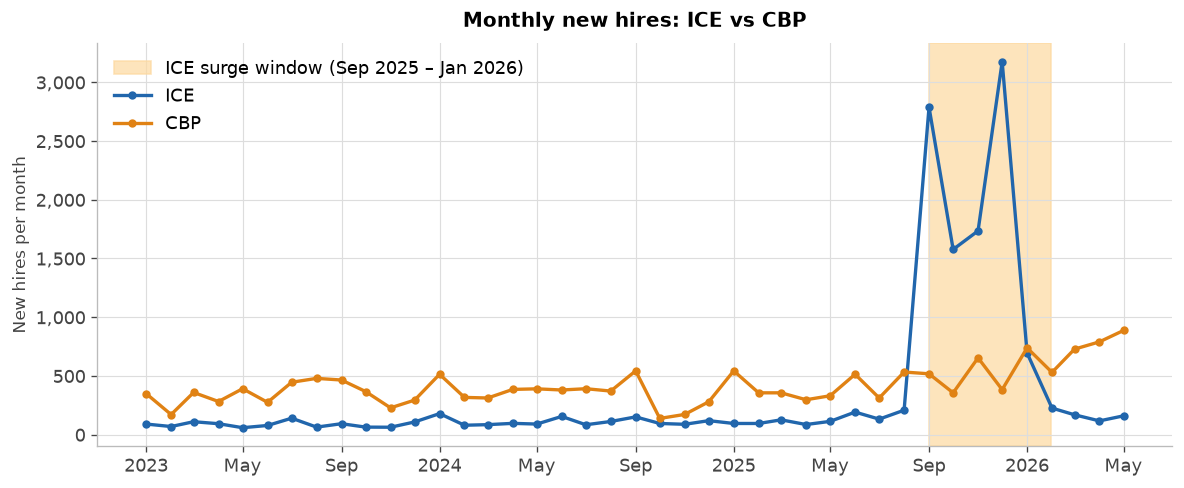

In [7]:
monthly = q(f"""
  SELECT event_ym,
    SUM(CASE WHEN agy_code='{surge.ICE}' AND {surge.NEW_HIRE} THEN count END) AS ICE,
    SUM(CASE WHEN agy_code='{surge.CBP}' AND {surge.NEW_HIRE} THEN count END) AS CBP
  FROM '{ACC}' WHERE event_ym >= '202301' GROUP BY 1 ORDER BY 1
""")
monthly["date"] = pd.to_datetime(monthly.event_ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.axvspan(pd.Timestamp("2025-09-01"), pd.Timestamp("2026-01-31"), color=SPAN, alpha=.7, zorder=0,
           label="ICE surge window (Sep 2025 – Jan 2026)")
ax.plot(monthly.date, monthly.ICE, marker="o", ms=4, lw=2, color=C_ICE, label="ICE")
ax.plot(monthly.date, monthly.CBP, marker="o", ms=4, lw=2, color=C_CBP, label="CBP")
ax.set(title="Monthly new hires: ICE vs CBP", ylabel="New hires per month")
comma_y(ax); date_x(ax); ax.legend(loc="upper left"); fig.tight_layout()
print(f"ICE new hires, Sep 2025 – Jan 2026: {int(monthly.query(chr(39)+'202509'+chr(39)+' <= event_ym <= '+chr(39)+'202601'+chr(39)).ICE.sum()):,}")

The ICE surge is a **sharp burst from Sep 2025 to Jan 2026** — about 10,000 hires in five months,
peaking in December — and then it drops back to roughly normal monthly levels. CBP shows no comparable
spike; it ramps up gradually and later, into 2026.

### 1b. How does this compare to *past* ICE hiring?

To see whether this is unusual for ICE, we extend the series back to 2006 (from the raw yearly files,
pulled by `src/history.py`; the agency codes were verified stable back to 2008 in §0) and join it to the
2018-onward cached extract.

ICE annual new hires — prior peak: 1,966 in 2009  |  2025: 10,322  (5.3x the prior peak)
CBP annual new hires — prior peak: 9,130 in 2008


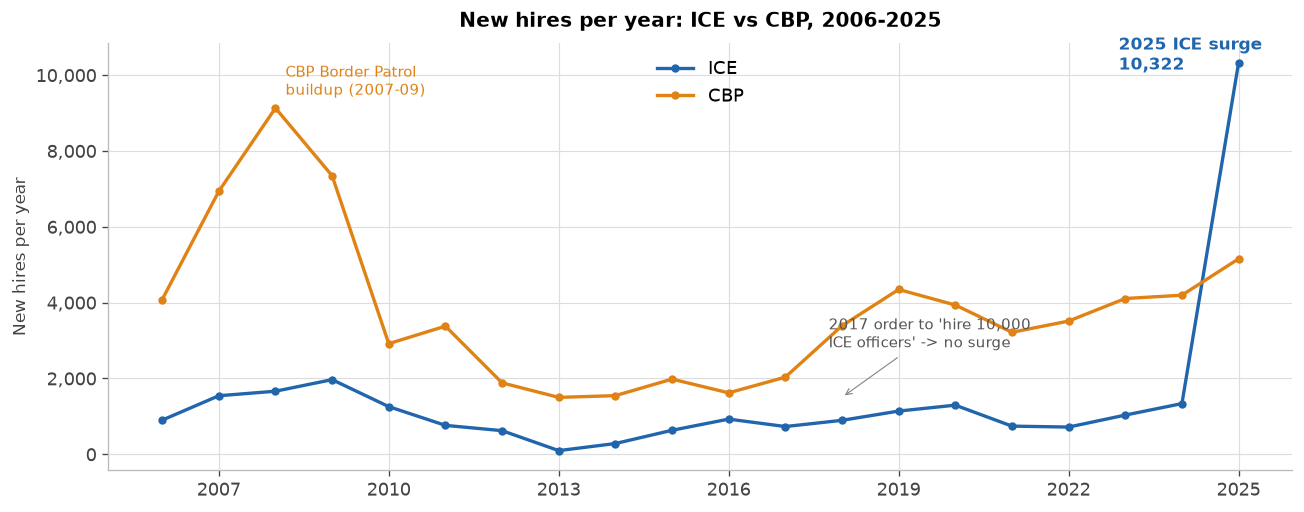

In [8]:
hist = pd.read_csv("data/ice_cbp_hires_history.csv")  # 2006-2017, from src/history.py
long = (hist.pivot_table(index="year", columns="agy", values="new_hires", aggfunc="sum")
            .rename(columns={"HSBB":"ICE","HSBD":"CBP"}))
recent = by_year.set_index("year").rename(columns={"ice_new_hires":"ICE","cbp_new_hires":"CBP"})[["ICE","CBP"]]
recent.index = recent.index.astype(int)
arc = pd.concat([long, recent]).sort_index()
arc = arc[arc.index <= 2025]  # 2026 is partial, drop it from the annual view
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(arc.index, arc.ICE, marker="o", ms=4, lw=2, color=C_ICE, label="ICE")
ax.plot(arc.index, arc.CBP, marker="o", ms=4, lw=2, color=C_CBP, label="CBP")
ax.annotate("CBP Border Patrol\nbuildup (2007-09)", (2008, arc.CBP.loc[2008]),
            textcoords="offset points", xytext=(6, 8), fontsize=9, color=C_CBP)
ax.annotate("2017 order to 'hire 10,000\nICE officers' -> no surge", (2018, 1500),
            textcoords="offset points", xytext=(-8, 30), fontsize=9, color="#555",
            arrowprops=dict(arrowstyle="->", lw=.7, color="#888"))
ax.annotate(f"2025 ICE surge\n{int(arc.ICE.loc[2025]):,}", (2025, arc.ICE.loc[2025]),
            textcoords="offset points", xytext=(-72, -4), fontsize=10, color=C_ICE, fontweight="bold")
ax.set(title="New hires per year: ICE vs CBP, 2006-2025", ylabel="New hires per year")
comma_y(ax); int_x(ax); ax.legend(loc="upper center"); fig.tight_layout()
print(f"ICE annual new hires — prior peak: {int(arc.ICE.loc[:2024].max()):,} in {int(arc.ICE.loc[:2024].idxmax())}"
      f"  |  2025: {int(arc.ICE.loc[2025]):,}  ({arc.ICE.loc[2025]/arc.ICE.loc[:2024].max():.1f}x the prior peak)")
print(f"CBP annual new hires — prior peak: {int(arc.CBP.loc[:2024].max()):,} in {int(arc.CBP.loc[:2024].idxmax())}")

**2025 is the biggest hiring year in ICE's record.** ICE's previous *annual* record was about 1,966 new
hires (2009); 2025's ~10,300 is roughly **5× ICE's all-time record and 8× its recent norm**. Notably, the
**2017 executive order that directed hiring 10,000 more ICE officers produced no visible surge** —
ICE hiring stayed at 700–1,300 a year through 2020. The only thing in this data that *looks* like 2025
is **CBP in 2007–2009**, when the Bush-era Border Patrol buildup drove 7,000–9,000 hires a year. So the
2025 ICE surge resembles CBP's 2007–2009 buildup, at a larger scale; such rapid buildups have
historically lost a quarter or more of new hires early (§4b).

## 2. Did it stick — did the hires stay on the rolls?

Hires are a monthly *flow*. The headcount file is the *level* — how many people are actually on the
payroll each month. If the surge is real and the hires stayed, ICE headcount should jump and hold.

ICE: Aug 2025 = 20,848  ->  peak Jan 2026 = 30,461  ->  May 2026 = 29,219
ICE change since the Jan 2026 peak: -1,242 (-4.1%)


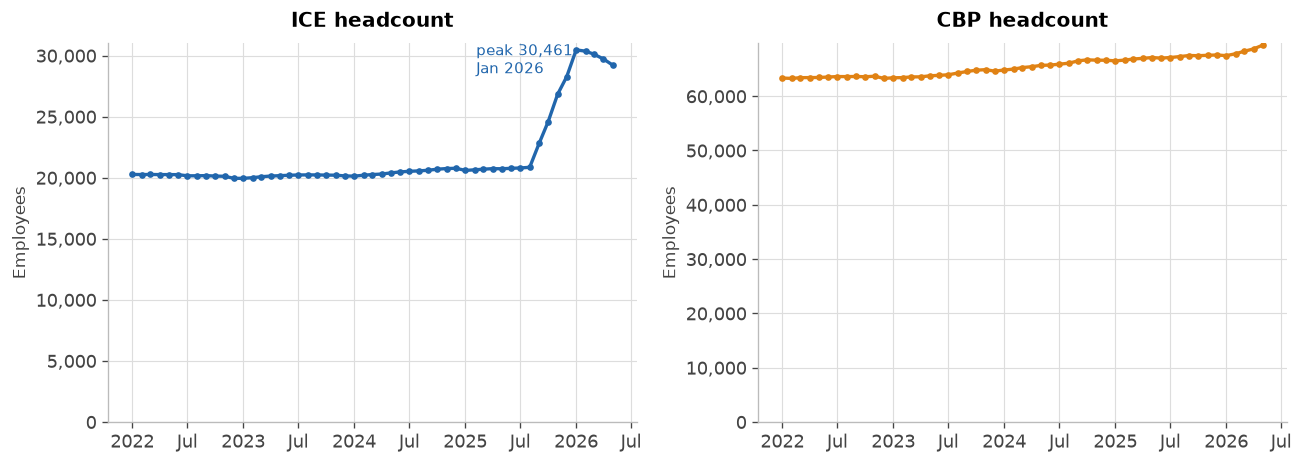

In [9]:
head = q(f"""
  SELECT snapshot_ym,
    SUM(CASE WHEN agy_code='{surge.ICE}' THEN count END) AS ICE,
    SUM(CASE WHEN agy_code='{surge.CBP}' THEN count END) AS CBP
  FROM '{EMP}' GROUP BY 1 ORDER BY 1
""")
head["date"] = pd.to_datetime(head.snapshot_ym, format="%Y%m")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, col, c in zip(axes, ["ICE", "CBP"], [C_ICE, C_CBP]):
    ax.plot(head.date, head[col], color=c, marker="o", ms=3, lw=2)
    ax.set(title=f"{col} headcount", ylabel="Employees"); ax.set_ylim(bottom=0)
    comma_y(ax); date_x(ax)
peak = head.loc[head.ICE.idxmax()]
axes[0].annotate(f"peak {int(peak.ICE):,}\n{ym_label(peak.snapshot_ym)}", (peak.date, peak.ICE),
                 textcoords="offset points", xytext=(-60, -14), fontsize=9, color=C_ICE)
fig.tight_layout()
aug25 = int(head.query("snapshot_ym=='202508'").ICE.iloc[0]); latest = int(head.iloc[-1].ICE)
print(f"ICE: {ym_label('202508')} = {aug25:,}  ->  peak {ym_label(peak.snapshot_ym)} = {int(peak.ICE):,}"
      f"  ->  {ym_label(head.iloc[-1].snapshot_ym)} = {latest:,}")
print(f"ICE change since the Jan 2026 peak: {latest-int(peak.ICE):+,} ({(latest/peak.ICE-1)*100:+.1f}%)")

The surge **did** reach the rolls: ICE headcount jumps from about 20,850 (Aug 2025) to a peak of
**30,461 in Jan 2026** — a ~46% expansion in five months. It has since **edged down** — by the latest
month ICE is at about 29,200, down roughly 1,200 (~4%) from the peak, even though some hiring continued.
That is a modest slip so far, and ICE remains well above its pre-surge level; but it is a decline, and
Sections 3–4 show it is the surge hires themselves leaving. CBP grows slowly and steadily, with no
reversal. (Headcount and the hires-minus-departures flow don't match exactly — a data quirk covered in
caveat 4 of §5, not part of the staffing story.)

## 3. Who are the surge hires? (Building a profile)

With no person IDs, to ask "are the *surge hires* the ones leaving" we first need a **profile** — the
job attributes that separate surge hires from normal ICE hires. We scan each attribute and rank its
values by how much more common they are among surge hires than in normal hiring. We measure that with
**"× vs. baseline" = (share among surge hires) ÷ (share among 2024 hires)**; a value of 3.0 means it is
three times as common in the surge. The two decisive attributes — **job series** and **pay plan** — are
shown as tables; grade, appointment type, and age are summarized in the reading that follows.

In [10]:
BASE  = "event_ym BETWEEN '202401' AND '202412'"
SURGE = f"event_ym BETWEEN '{surge.SURGE_WINDOW[0]}' AND '{surge.SURGE_WINDOW[1]}'"
WH = f"agy_code='{surge.ICE}' AND {surge.NEW_HIRE}"
Bt, St = con.execute(f"SELECT SUM(CASE WHEN {BASE} THEN count END), SUM(CASE WHEN {SURGE} THEN count END) FROM '{ACC}' WHERE {WH}").fetchone()

def fingerprint(col, min_n=150):
    d = q(f"SELECT {col} AS value, SUM(CASE WHEN {BASE} THEN count END) b, SUM(CASE WHEN {SURGE} THEN count END) s FROM '{ACC}' WHERE {WH} GROUP BY 1")
    d[["b","s"]] = d[["b","s"]].fillna(0)
    d["% of surge"]    = (100*d.s/St).round(1)
    d["% of 2024"]     = (100*d.b/Bt).round(1)
    d["× vs 2024"]     = (d["% of surge"]/d["% of 2024"]).round(1)
    d["surge hires"]   = d.s.astype(int)
    return (d[d.s>=min_n].sort_values("s", ascending=False)
             .rename(columns={"value": col})
             [[col,"surge hires","% of surge","% of 2024","× vs 2024"]].reset_index(drop=True))

labels = {"occupational_series_code":"Job series", "pay_plan_code":"Pay plan",
          "appointment_type":"Appointment type", "grade":"Grade", "age_bracket":"Age bracket"}
display(Markdown(f"**ICE new hires — 2024 baseline = {int(Bt):,} &nbsp;·&nbsp; surge window = {int(St):,}**"))
for c in ["occupational_series_code","pay_plan_code"]:
    fp_df = fingerprint(c)
    if c == "occupational_series_code":
        fp_df[c] = fp_df[c].map(series_label)   # show "1801 — General Inspection..." not just "1801"
    fp_df = fp_df.rename(columns={c: labels[c]})
    display(Markdown(f"**{labels[c]}**"))
    display(show(fp_df, pct=["% of surge","% of 2024"]))

**ICE new hires — 2024 baseline = 1,334 &nbsp;·&nbsp; surge window = 9,970**

**Job series**

Job series,surge hires,% of surge,% of 2024,× vs 2024
"1801 — General Inspection, Investigation, Enforcement, and Compliance Series","6,346",63.7%,19.9%,3.2
1811 — Criminal Investigation,"2,282",22.9%,19.2%,1.2
0905 — Attorney,980,9.8%,25.3%,0.4


**Pay plan**

Pay plan,surge hires,% of surge,% of 2024,× vs 2024
GL,"6,749",67.7%,32.6%,2.1
GS,"3,216",32.3%,67.1%,0.5


**Reading the profile:**

- **Job series** is the sharpest marker: series **1801** (*General Inspection, Investigation, Enforcement,
  and Compliance* — the ICE immigration-enforcement / deportation officer series) is about 64% of surge
  hires versus 20% in normal hiring (**3.2× as common**); adding series **1811** (*Criminal Investigation*)
  covers about 87% of the surge.
- **Pay plan `GL`** (the entry law-enforcement officer pay plan) is about 68% of surge hires versus 33%
  normally (**2.1×**), at grades **GL-05/07/09**.
- Two secondary markers: an unusual share of **term (non-permanent) appointments** (**3.0×**), and an
  **older age mix** (the 50–59 brackets run 1.5–2.8× normal) — atypical for entry-level law-enforcement.

So we define the surge hires as **pay plan `GL` + job series 1801/1811**. Almost no one at ICE held those
jobs before the surge, so any jump in departures from them is, by construction, the surge hires — **and
this does not use length of service**, which is muddied by prior federal experience (see §5).

## 4. Are the surge hires the ones leaving — and are they quitting or being let go?

Now apply the same profile to **departures**: exits from the GL-1801/1811 jobs over time.

In [11]:
fp = surge.SURGE_FP
fp_sep_year = q(f"""
  SELECT substr(event_ym,1,4) AS year, SUM(count) AS fp_separations,
    SUM(CASE WHEN separation_category='QUIT' THEN count END) AS quits,
    SUM(CASE WHEN separation_category LIKE 'TERMINATION%' THEN count END) AS terminations
  FROM '{SEP}' WHERE agy_code='{surge.ICE}' AND {fp} GROUP BY 1 ORDER BY 1
""")
show(fp_sep_year.rename(columns={"year":"Year","fp_separations":"Departures",
                                 "quits":"Quits","terminations":"Terminations"}))  # 2026 is 5 months only

Year,Departures,Quits,Terminations
2018,28,19,—
2019,27,7,—
2020,46,16,1
2021,43,29,—
2022,37,19,—
2023,27,12,—
2024,32,21,—
2025,730,557,146
2026,"1,058",703,306


Departures from these jobs were a **flat 27–46 per year from 2018 through 2024**. They jump to **730 in
2025** and **1,058 in just the first five months of 2026** — a yearly pace around 2,500, roughly
**50–60× the pre-surge norm**. The exits begin the same month the hiring does (Oct 2025). The monthly
picture, next to hiring, is in the chart further down.

### Let go, or leaving on their own?

The departure category tells voluntary quits apart from involuntary terminations.

In [12]:
why = q(f"""
  SELECT separation_category, SUM(count) AS n
  FROM '{SEP}' WHERE agy_code='{surge.ICE}' AND {fp} AND event_ym>='202509'
  GROUP BY 1 ORDER BY n DESC
""")
why["share_%"] = (100*why.n/why.n.sum()).round(1)
q_ct = int(why.loc[why.separation_category=='QUIT','n'].iloc[0])
t_ct = int(why.loc[why.separation_category.str.startswith('TERMINATION'),'n'].sum())
display(show(why.rename(columns={"separation_category":"Departure type","n":"People"}), pct=["share_%"]))
print(f"Voluntary QUIT: {q_ct:,} ({100*q_ct/why.n.sum():.0f}%)   Involuntary TERMINATION: {t_ct:,} ({100*t_ct/why.n.sum():.0f}%)")

Departure type,People,share_%
QUIT,"1,230",71.0%
TERMINATION (EXPIRED APPT/OTHER),449,25.9%
OTHER SEPARATION,27,1.6%
TRANSFER OUT - INDIVIDUAL TRANSFER,25,1.4%
RETIREMENT - VOLUNTARY,2,0.1%


Voluntary QUIT: 1,230 (71%)   Involuntary TERMINATION: 449 (26%)


**Most are voluntary departures, not removals.** Of departures from the surge hires since Sep 2025,
about **71% are voluntary quits** and about **26% are terminations** coded "expired appointment / other."
The termination category combines **term (non-permanent) appointments reaching their end** (the 3×
term-appointment share from §3) with any probationary removals, and the data does not separate the two.
So about 3 in 4 left voluntarily, and about 1 in 4 had an appointment end (some involuntary, some
term-limited).

Month,Hires,Quits,Appointment ended,Departures total
Jun 2025,98,3,0,4
Jul 2025,62,5,1,8
Aug 2025,109,3,2,8
Sep 2025,"1,729",45,6,52
Oct 2025,802,205,65,270
Nov 2025,"1,078",156,39,199
Dec 2025,"2,647",121,33,154
Jan 2026,493,155,62,231
Feb 2026,131,189,66,259
Mar 2026,77,172,83,270


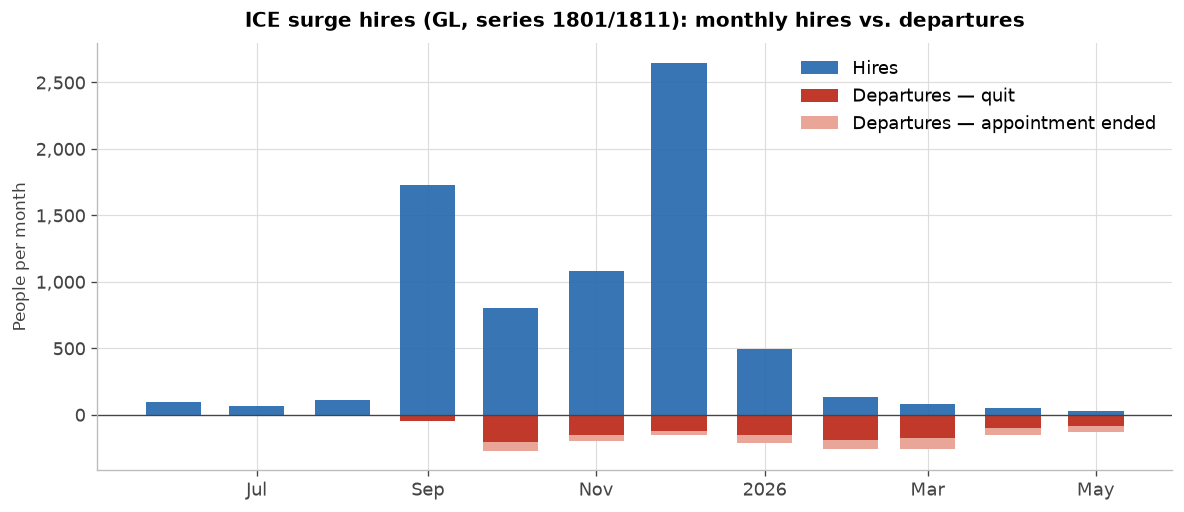

In [13]:
# Hires (up) vs. departures (down, split into quit vs. term-ended), on ONE shared scale so the
# proportion leaving reads consistently: departures are small next to the hiring wave, then dominate
# once hiring stops.
comp = q(f"""
  WITH h AS (SELECT event_ym, SUM(count) hires FROM '{ACC}' WHERE agy_code='{surge.ICE}' AND {surge.NEW_HIRE} AND {fp} GROUP BY 1),
       s AS (SELECT event_ym,
               SUM(CASE WHEN separation_category='QUIT' THEN count END) quits,
               SUM(CASE WHEN separation_category LIKE 'TERMINATION%' THEN count END) terms,
               SUM(count) exits
             FROM '{SEP}' WHERE agy_code='{surge.ICE}' AND {fp} GROUP BY 1)
  SELECT COALESCE(h.event_ym,s.event_ym) event_ym, COALESCE(hires,0) hires,
         COALESCE(quits,0) quits, COALESCE(terms,0) terms, COALESCE(exits,0) exits
  FROM h FULL JOIN s USING(event_ym)
  WHERE COALESCE(h.event_ym,s.event_ym) >= '202506' ORDER BY 1
""")
comp["date"] = pd.to_datetime(comp.event_ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(comp.date, comp.hires, width=20, color=C_ICE, alpha=.9, label="Hires")
ax.bar(comp.date, -comp.quits, width=20, color=C_EXIT, label="Departures — quit")
ax.bar(comp.date, -comp.terms, bottom=-comp.quits, width=20, color="#e8a598",
       label="Departures — appointment ended")
ax.axhline(0, color="#444", lw=.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{abs(x):,.0f}"))
ax.set(title="ICE surge hires (GL, series 1801/1811): monthly hires vs. departures",
       ylabel="People per month"); date_x(ax); ax.legend(loc="upper right"); fig.tight_layout()
comp_disp = comp.assign(Month=comp.event_ym.map(ym_label))[["Month","hires","quits","terms","exits"]]
comp_disp.columns = ["Month","Hires","Quits","Appointment ended","Departures total"]
display(show(comp_disp))

A wall of hiring in **Oct 2025 – Jan 2026**, then hiring falls off a cliff while departures stay
elevated — so from about Feb 2026 the group **shrinks every month**. That is the mechanism behind the
headcount reversal in §2.

### 4b. How many leave soon after being hired — and is that rate unusual?

Because these jobs were nearly empty before the surge, we can watch the **whole group's** departures pile
up against its own hires — a running early-departure rate that does **not** depend on length of service
(so it also captures the ~1/3 of surge hires who had prior federal experience).

By May 2026: 1,733 of 7,033 surge hires have left = 24.6% — all within their first year, and still climbing.


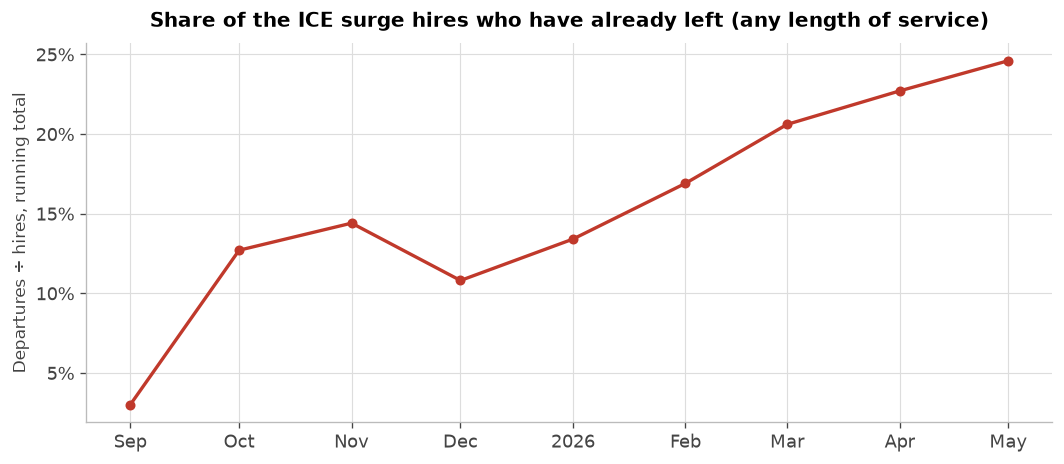

In [14]:
cohort = q(f"""
  WITH h AS (SELECT event_ym, SUM(count) hires FROM '{ACC}' WHERE agy_code='{surge.ICE}' AND {surge.NEW_HIRE} AND {fp} GROUP BY 1),
       s AS (SELECT event_ym, SUM(count) exits FROM '{SEP}' WHERE agy_code='{surge.ICE}' AND {fp} GROUP BY 1)
  SELECT m.event_ym,
    SUM(COALESCE(hires,0)) OVER w AS cum_hires,
    SUM(COALESCE(exits,0)) OVER w AS cum_exits,
    ROUND(100.0*SUM(COALESCE(exits,0)) OVER w / NULLIF(SUM(COALESCE(hires,0)) OVER w,0),1) AS pct_of_cohort_exited
  FROM (SELECT event_ym FROM h UNION SELECT event_ym FROM s) m
  LEFT JOIN h USING(event_ym) LEFT JOIN s USING(event_ym)
  WHERE m.event_ym >= '202509' WINDOW w AS (ORDER BY m.event_ym) ORDER BY m.event_ym
""")
cohort["date"] = pd.to_datetime(cohort.event_ym, format="%Y%m")
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cohort.date, cohort.pct_of_cohort_exited, marker="o", ms=5, lw=2, color=C_EXIT)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set(title="Share of the ICE surge hires who have already left (any length of service)",
       ylabel="Departures ÷ hires, running total"); date_x(ax); fig.tight_layout()
final = cohort.iloc[-1]
print(f"By {ym_label(final.event_ym)}: {int(final.cum_exits):,} of {int(final.cum_hires):,} surge hires have left "
      f"= {final.pct_of_cohort_exited}% — all within their first year, and still climbing.")

About **one in four** surge hires (~25%; roughly 1,700 of ~7,000) has already left within about 0–8
months, and the share climbs every month because hiring stopped while departures continue. Is that
unusual? We need a **genuinely similar group** — not the ~900 pre-surge ICE officers, which is too small.
The natural comparison is **CBP's entry law-enforcement officers**: Border Patrol Agents (series 1896,
*Border Patrol Enforcement*, pay plan GL) and CBP Officers (series 1895, *Customs and Border Protection*).
Same DHS enforcement mission, same entry grades, same academy onboarding — but hired in volume every
year, so they have a normal early-departure track record.

Is ~25% in a few months a lot? We can't answer that with an ICE *first-year* rate — these hires arrived
Sep 2025 – Jan 2026, so by May 2026 they have been on the job only a few months, well short of a full
year, and annualizing a partial year would mislead. What we *can* compute is the **completed** first-year
rate for a genuinely similar group: **CBP's entry
law-enforcement officers** — Border Patrol Agents (series 1896, GL) and CBP Officers (series 1895). Same
DHS enforcement mission, same entry grades, same academy onboarding, but hired in volume every year, so
their cohorts have each had a full year or more to play out. Those give honest full-year benchmarks to
hold ICE's partial-year loss against — a comparison of *horizons*, not rate-against-rate. (The CBP
measure: departures with under a year of service ÷ new-entrant hires.)

In [15]:
def first_year_rate(agy, fp_, y0, y1):
    d = q(f"""
      WITH h AS (SELECT SUM(CASE WHEN {surge.dbl('length_of_service_years')}<0.15 THEN count END) hires
                 FROM '{ACC}' WHERE agy_code='{agy}' AND {surge.NEW_HIRE} AND {fp_}
                   AND substr(event_ym,1,4) BETWEEN '{y0}' AND '{y1}'),
           s AS (SELECT SUM(CASE WHEN {surge.dbl('length_of_service_years')}<1 THEN count END) exits_lt1yr
                 FROM '{SEP}' WHERE agy_code='{agy}' AND {fp_}
                   AND substr(event_ym,1,4) BETWEEN '{y0}' AND '{y1}')
      SELECT hires, exits_lt1yr, ROUND(100.0*exits_lt1yr/NULLIF(hires,0),1) first_yr_sep_pct FROM h,s
    """).iloc[0]
    return int(d.hires), int(d.exits_lt1yr), d.first_yr_sep_pct

# No ICE row on purpose: these hires are only a few months into their first year, so an ICE first-year
# rate isn't computable yet. ICE's observed loss so far (~25%, chart above) is compared to these full-year
# CBP benchmarks by horizon, in words, below.
rows = [
  ("CBP Border Patrol (1896 GL) — 2023-24 classes", "HSBD", "pay_plan_code='GL' AND occupational_series_code='1896'", "2023","2024"),
  ("CBP Border Patrol (1896 GL) — 2019-21 rapid-hire", "HSBD", "pay_plan_code='GL' AND occupational_series_code='1896'", "2019","2021"),
  ("CBP Officer (1895) — 2023-24 classes", "HSBD", "occupational_series_code='1895'", "2023","2024"),
]
cbp = pd.DataFrame([(lbl,)+first_year_rate(a,f,y0,y1) for lbl,a,f,y0,y1 in rows],
                   columns=["group","new_entrant_hires","exits_under_1yr","first_yr_sep_%"])
display(Markdown("**Reference — CBP departures within the _full_ first year of service (completed cohorts)**"))
display(show(cbp.rename(columns={"group":"CBP entry law-enforcement group","new_entrant_hires":"New-entrant hires",
                                 "exits_under_1yr":"Left within first year","first_yr_sep_%":"First-year rate"}),
             pct=["First-year rate"]))
print(f"ICE surge hires so far (chart above): {int(final.cum_exits):,} of {int(final.cum_hires):,} left "
      f"= {final.pct_of_cohort_exited}% — before their first year is complete, so not shown as a rate.")

**Reference — CBP departures within the _full_ first year of service (completed cohorts)**

CBP entry law-enforcement group,New-entrant hires,Left within first year,First-year rate
CBP Border Patrol (1896 GL) — 2023-24 classes,"1,976",225,11.4%
CBP Border Patrol (1896 GL) — 2019-21 rapid-hire,"3,275",944,28.8%
CBP Officer (1895) — 2023-24 classes,"2,075",218,10.5%


ICE surge hires so far (chart above): 1,733 of 7,033 left = 24.6% — before their first year is complete, so not shown as a rate.


**The verdict.** We can't state an ICE *first-year* rate — the cohort's first year isn't over (these
hires are only a few months in), and annualizing a partial year would mislead. What we can say: ICE has
**already lost about 25%** before that first year is up. For a full-year reference, CBP's comparable entry classes
lose about **10–11% over a whole year** in normal times, and even CBP's roughest rapid-hire cohort —
Border Patrol in **2019–21** — lost about **29% over a whole year**. So in well under a year ICE has
already passed CBP's steady-state full-year loss and is closing on CBP's own worst rapid-hire surge —
near the high end of that range, not beyond it, with its first year not yet complete.

## 5. Net effect, and what the data can and cannot say

**What the data supports:**

- The 2025 DHS surge was **overwhelmingly ICE** (about 8× normal ICE hiring; CBP barely above trend),
  concentrated in **Sep 2025 – Jan 2026** and in **entry law-enforcement jobs** (pay plan GL, series
  1801/1811, grades 05/07/09).
- It **reached the rolls** — ICE headcount grew about 46% (20.9k → 30.5k) — and has since **slipped
  modestly**, about 1,200 (~4%) off the January peak, still declining as the cohort leaves.
- The shrinkage is the **surge hires themselves**, identified by job, pay plan, and grade (not length of
  service). Departures from those jobs went from ~30/year to ~1,000 in five months; **about 71% are
  voluntary quits**, about 26% involuntary terminations, the small remainder transfers and retirements.
- Early loss is **about 25% before the cohort's first year is even complete**, so we don't state it as a
  first-year rate. For reference, CBP's comparable entry classes shed ~10–11%
  over a *full* year normally and ~29% in their 2019–21 rapid-hire surge; ICE is already near the high end
  of that range with months still to run.

**Caveats (each checked or bounded in §0):**

1. **Counts, not people.** Records are personnel actions, not tracked individuals; we match *departing*
   jobs to *hiring* jobs. We can't prove a given leaver was a specific fall-2025 hire — the match is
   tight only because ICE had almost no one in these entry jobs before the surge (~900).
2. **We track the ~68% we can.** The profile (GL, 1801/1811) covers about 68% of surge hires — the entry
   officers. The rest (GS officers and ~980 attorneys) sit in jobs that already had large standing
   populations, so their attrition can't be isolated the same way; the ~25% early-exit figure is for the
   entry-officer core, which is the group of policy interest.
3. **Length of service ≠ time in this job.** `length_of_service_years` is *total federal service*; about
   30% of 2025 ICE new hires arrived with 3+ years of prior service — a mix of **veterans**
   (military-service credit) and **prior federal civilians** (rehires), not transfers (those are 0.4%,
   §0). A length-of-service-based cohort would misclassify roughly a third of them — exactly why we
   profile by job and grade instead.
4. **Headcount and flow don't reconcile** (§2): the flow lags the headcount change by ~15–20%, so we use
   headcount for staffing levels and departures for exits, never chained. The "declining headcount"
   claim rests on complete headcount snapshots, not on provisional flows.
5. **Recent months are provisional.** Normal months are ~99% complete right away, but surge-era
   processing lagged more (Dec 2025 was only ~30% complete in its own file), so the most recent *flow*
   months carry extra uncertainty and, if anything, **understate** recent exits. Headcount snapshots are
   unaffected.
6. **Term vs. cause.** "Termination (expired appointment / other)" mixes term-appointment expirations
   with any for-cause removals; the ~26% involuntary slice can't be split further.
7. **Redaction preserves totals.** The most-masked field (work location, ~98% of these hires) is
   relabeled, not dropped, so headcount and job totals lose no one (§0).
8. **Not a buyout artifact.** A direct check of the separations `drp_indicator` field (table below)
   flags **0 of the 1,733 cohort departures** — and 0 of all ~3,450 ICE departures in this window — as
   deferred-resignation-program exits. The cohort's attrition is ordinary quits and appointment endings,
   not the 2025 government-wide buyout.

**Buyout check (caveat 8).** Surge-cohort departures by the separations `drp_indicator` flag — none are
deferred-resignation-program exits.

In [16]:
drp = q(f"""
  SELECT COALESCE(drp_indicator,'(blank)') AS drp_indicator, SUM(count) AS departures
  FROM '{SEP}' WHERE agy_code='{surge.ICE}' AND {fp} AND event_ym>='202509'
  GROUP BY 1 ORDER BY departures DESC
""")
show(drp.rename(columns={"drp_indicator":"DRP flag (Y = deferred-resignation program)",
                         "departures":"Cohort departures"}))

DRP flag (Y = deferred-resignation program),Cohort departures
N,"1,733"


**The stock-vs-flow gap behind caveat 4, month by month.** ICE headcount change vs. hires − departures
around the surge: they tell the same story but don't match exactly, most visibly at the Dec 2025 / Jan
2026 boundary, where December-effective hires only land on the January headcount.

In [17]:
recon = q(f"""
  WITH e AS (SELECT snapshot_ym ym, SUM(count) hc FROM '{EMP}' WHERE agy_code='{surge.ICE}' GROUP BY 1),
       a AS (SELECT event_ym ym, SUM(count) acc FROM '{ACC}' WHERE agy_code='{surge.ICE}' GROUP BY 1),
       s AS (SELECT event_ym ym, SUM(count) sep FROM '{SEP}' WHERE agy_code='{surge.ICE}' GROUP BY 1)
  SELECT e.ym, hc, hc - LAG(hc) OVER (ORDER BY e.ym) AS d_headcount,
         acc, sep, acc - sep AS net_flow
  FROM e LEFT JOIN a ON a.ym=e.ym LEFT JOIN s ON s.ym=e.ym
  WHERE e.ym BETWEEN '202508' AND '202603' ORDER BY e.ym
""")
recon_disp = recon.assign(Month=recon.ym.map(ym_label))[["Month","hc","d_headcount","acc","sep","net_flow"]]
recon_disp.columns = ["Month","Headcount","Change vs. prior month","Hires","Departures","Hires − departures"]
show(recon_disp)

Month,Headcount,Change vs. prior month,Hires,Departures,Hires − departures
Aug 2025,"20,848",—,214,125,89
Sep 2025,"22,799","1,951","2,792",182,"2,610"
Oct 2025,"24,593","1,794","1,582",440,"1,142"
Nov 2025,"26,827","2,234","1,736",334,"1,402"
Dec 2025,"28,272","1,445","3,203",493,"2,710"
Jan 2026,"30,461","2,189",700,479,221
Feb 2026,"30,355",-106,226,454,-228
Mar 2026,"30,102",-253,172,439,-267


In [18]:
prior = q(f"""
  SELECT CASE WHEN {surge.dbl('length_of_service_years')} < 0.15 THEN 'Truly new (under 2 months of service)'
              WHEN {surge.dbl('length_of_service_years')} < 3 THEN 'Some prior federal service (under 3 yr)'
              ELSE '3+ years of prior federal service' END AS prior_experience,
         SUM(count) AS n
  FROM '{ACC}' WHERE agy_code='{surge.ICE}' AND {surge.NEW_HIRE} AND substr(event_ym,1,4)='2025'
  GROUP BY 1 ORDER BY n DESC
""")
prior["share_%"] = (100*prior.n/prior.n.sum()).round(1)
show(prior.rename(columns={"prior_experience":"Prior federal service","n":"People"}), pct=["share_%"])

Prior federal service,People,share_%
Truly new (under 2 months of service),"6,687",64.8%
3+ years of prior federal service,"3,061",29.7%
Some prior federal service (under 3 yr),574,5.6%


About a third of 2025 ICE "new hires" arrived with **3+ years of prior federal service** — rehires,
conversions, and moves from other agencies entering as new appointments. This is exactly why the surge
hires have to be identified by **the job they were hired into**, not by how long they've been on a
federal payroll.

---
*Source: OPM/EHRI hires, departures, and headcount via `impactproject/opm-ehri-data`; extract built by
`src/extract.py`; the surge-hire definition and windows are in `src/surge.py`. ICE = HSBB, CBP = HSBD.
Data through May 2026; the most recent 1–2 months are provisional.*